In [12]:
!pip install -q selenium
!pip install -q webdriver-manager
!pip install -q beautifulsoup4 fake-useragent pandas tqdm requests

!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt-get install -y -q ./google-chrome-stable_current_amd64.deb
!rm google-chrome-stable_current_amd64.deb

Reading package lists...
Building dependency tree...
Reading state information...
google-chrome-stable is already the newest version (147.0.7727.55-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [13]:
import requests
import pandas as pd
import re
from bs4 import BeautifulSoup
from tqdm import tqdm
from time import sleep
import json
import logging
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

In [14]:
config = {
    "logging_enabled": True,
    "log_level": "INFO",
    "log_file": "scraper.log"
}

In [15]:
if config['logging_enabled']:
  logging.basicConfig(
      level=getattr(logging, config['log_level'].upper(), logging.INFO),
      filename=config['log_file'],
      format='%(asctime)s - %(levelname)s - %(funcName)s - %(message)s',
      force=True,
      datefmt='%H:%M:%S')
  logging.info('Логирование включено')

In [16]:
options = Options()
options.binary_location = '/usr/bin/google-chrome'
options.add_argument('--headless=new')
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')
options.add_argument('--disable-gpu')

service = Service(ChromeDriverManager().install())
browser = webdriver.Chrome(service=service, options=options)
logging.info('Selenium browser успешно создан')

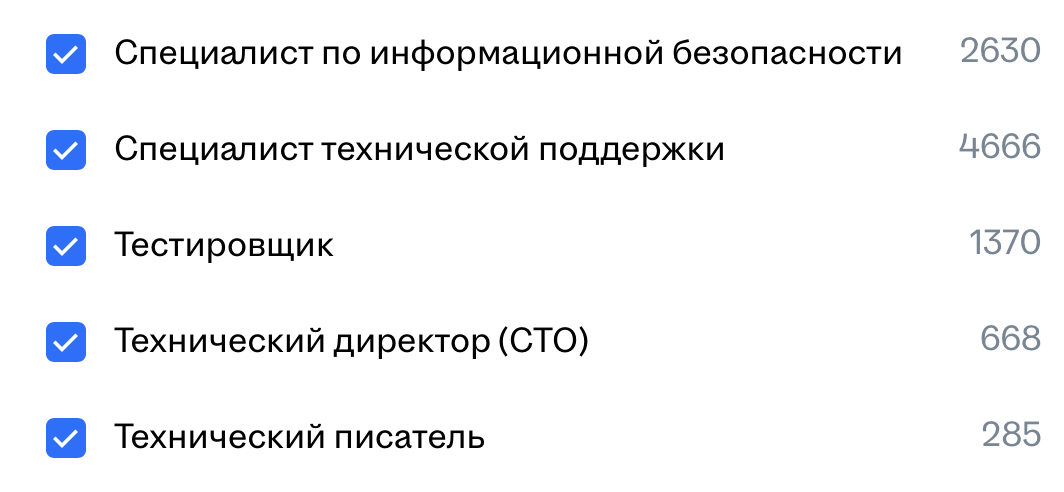

In [17]:
url_hh5 = 'https://hh.ru/search/vacancy?area=113&L_save_area=true&search_field=name&search_field=company_name&search_field=description&enable_snippets=true&professional_role=126&professional_role=125&professional_role=124&professional_role=121&professional_role=116'
page = requests.get(url_hh5)
browser.get(url_hh5)
sleep(3)
html = browser.page_source
soup = BeautifulSoup(html, 'html.parser')
browser.title
logging.info(f'Страница открывается: {url_hh5}')
def get_page(p):
  url = f'{url_hh5}&page={p}'
  browser.get(url)
  sleep(3)
  logging.info(f'Открыта страница с ваканиями: {url}')
  soup = BeautifulSoup(browser.page_source, 'html.parser')

  urls = []

  for link in soup.find_all('a'):
    if link.get('href') is not None and 'hh.ru/vacancy/' in link.get('href'):
      href = link.get('href').split('?')[0]
      urls.append(href)
  urls = list(set(urls))
  logging.info(f'На странице {p} найдено {len(urls)} уникальных ссылок')
  return urls
def GetVacancy(url0):
  browser.get(url0)
  sleep(3)
  soup0 = BeautifulSoup(browser.page_source, 'html.parser')

  try:
    title = soup0.find('h1')
    title = title.get_text(strip=True)
  except AttributeError:
    title = None

  try:
    company = soup0.find(attrs={'data-qa': 'vacancy-company-name'})
    company = company.get_text(strip=True)
  except AttributeError:
    company = None

  try:
    salary = soup0.find(attrs={'data-qa': 'vacancy-salary'})
    salary = salary.get_text(' ', strip=True)
  except AttributeError:
    salary = None

  try:
    experience = soup0.find(attrs={'data-qa': 'vacancy-experience'})
    experience = experience.get_text(strip=True)
  except AttributeError:
    experience = None

  try:
    location = soup0.find(attrs={'data-qa': 'vacancy-view-location'})
    location = location.get_text(' ', strip=True)
  except AttributeError:
    location = None

  try:
    description = soup0.find(attrs={'data-qa': 'vacancy-description'})
    description = description.get_text(' ', strip=True)
  except AttributeError:
    description = None

  try:
    date = soup0.find('meta', {'property': 'article:published_time'}).get('content')
  except AttributeError:
    date = None

  try:
    tags_raw = soup0.find('ul', class_='vacancy-skill-list--JsTYRZ5o6dsoavK7')
    tags_raw = tags_raw.get_text(', ', strip=True)
  except AttributeError:
    tags_raw = None

  result = {
      'url': url0,
      'title': title,
      'date': date,
      'company': company,
      'salary': salary,
      'experience': experience,
      'location': location,
      'tags_raw': tags_raw,
      'description': description,
      'source': 'hh_ru'}
  logging.info(f'Вакансия {title} спарсена')
  return result

In [18]:
infa = []

for p in tqdm(range(0,40)):
  try:
    infa.extend(get_page(p))
    sleep(5)
  except:
    print(p)
    logging.exception(f'Ошибка при обработке страницы {p}')
logging.info(f'Всего собрано {len(infa)} ссылок')

100%|██████████| 40/40 [09:16<00:00, 13.91s/it]


In [19]:
vacancies_hh = []

for link in tqdm(infa):
  try:
    print(link)
    res = GetVacancy(link)
    vacancies_hh.append(res)
    sleep(5)
  except:
    print(link)
    logging.exception(f'Ошибка при парсинге вакансии {link}')
logging.info(f'Всего спарсено {len(vacancies_hh)} вакансий')

  0%|          | 0/2000 [00:00<?, ?it/s]

https://hh.ru/vacancy/132009820


  0%|          | 1/2000 [00:14<8:15:43, 14.88s/it]

https://hh.ru/vacancy/131815782


  0%|          | 2/2000 [00:26<7:17:44, 13.15s/it]

...

100%|█████████▉| 1998/2000 [6:21:02<00:23, 11.57s/it]

https://hh.ru/vacancy/131255944


100%|█████████▉| 1999/2000 [6:21:13<00:11, 11.42s/it]

https://hh.ru/vacancy/132021566


100%|██████████| 2000/2000 [6:21:25<00:00, 11.44s/it]


In [22]:
df = pd.DataFrame(vacancies_hh)
df.head(2)
logging.info(f'Таблица вакансий hh5 создана')
df.to_csv('hh5.csv')
logging.info(f'Файл hh5 загружен')

In [23]:
browser.quit()
logging.info(f'Browser закрыт')